In [1]:
import pandas as pd

df = pd.read_csv("/content/heart.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

Shape: (1025, 14)

Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [3]:
print(df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std      0.526027   22.903527    0.4

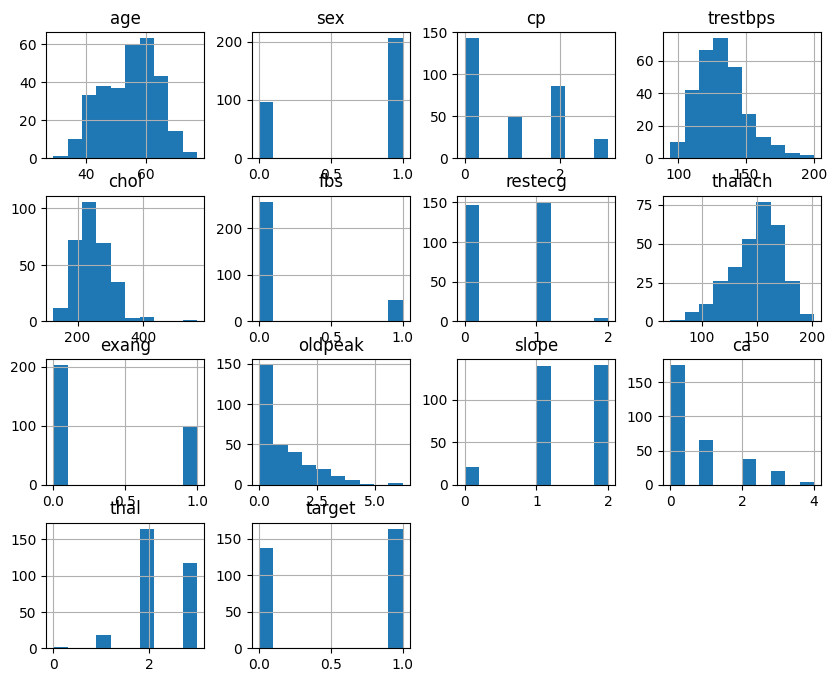

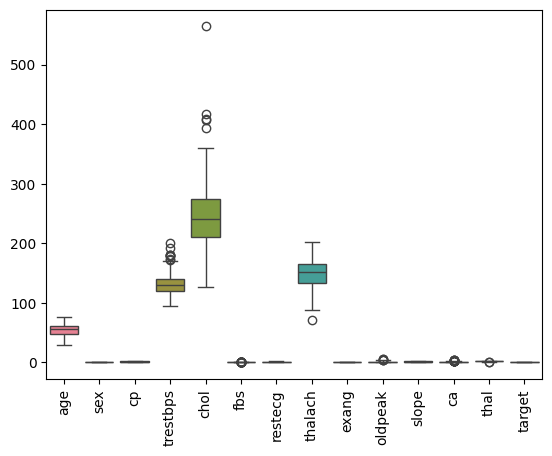

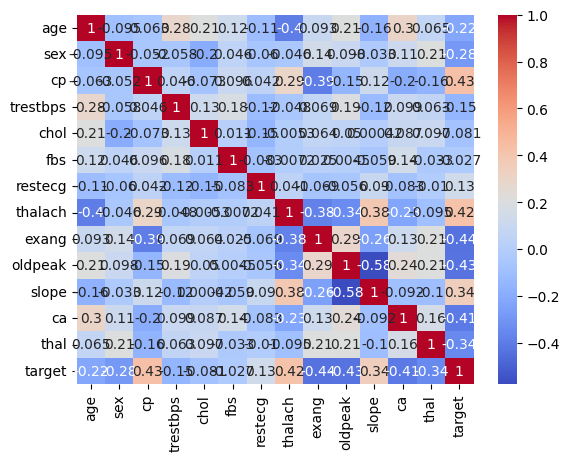

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary
print(df.describe())

# Histogram
df.hist(figsize=(10,8))
plt.show()

# Boxplot
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier()

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Logistic Regression
pred_lr = lr.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

# Decision Tree
pred_dt = dt.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))

# Random Forest
pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))

LR Accuracy: 0.7868852459016393
[[22 10]
 [ 3 26]]
DT Accuracy: 0.7049180327868853
[[24  8]
 [10 19]]
RF Accuracy: 0.819672131147541
[[24  8]
 [ 3 26]]


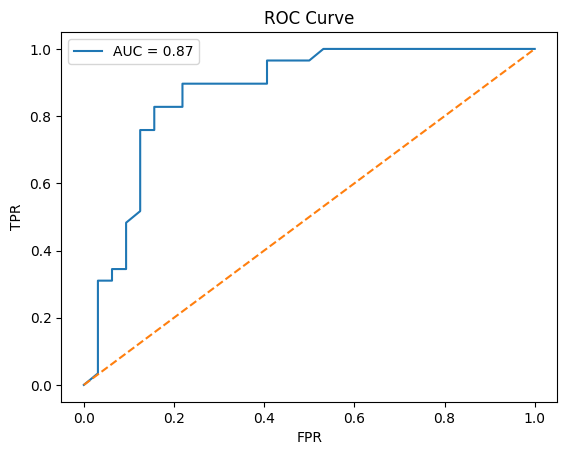

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
import numpy as np

input_data = [63,1,3,145,233,1,0,150,0,2.3,0,0,1]

input_array = np.array(input_data).reshape(1,-1)

prediction = rf.predict(input_array)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("Healthy")

Healthy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [11]:
import pickle

pickle.dump(rf, open("heart_model.pkl", "wb"))

In [14]:
!pip install streamlit
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("heart_model.pkl", "rb"))

st.title("Heart Disease Prediction")

age = st.number_input("Age")

if st.button("Predict"):
    data = np.array([[age,1,3,145,233,1,0,150,0,2.3,0,0,1]])
    result = model.predict(data)

    if result[0] == 1:
        st.error("Heart Disease Detected")
    else:
        st.success("Healthy")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 74.4 MB/s eta 0:00:00


2026-06-03 11:17:24.260 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 11:17:24.465 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-03 11:17:24.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 11:17:24.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 11:17:24.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 11:17:24.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 11:17:24.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 11:17:24.475 Thread 'MainThread': mi